# EPIC — EXP033 False-Positive Study

Здесь мы **не обучаем новую модель**.

Берём уже обученный `EXP033 @ 10k`:

```text
NO BPE
base-level CNN
RF = 2053 bp
32-bp regional head
```

и исследуем **hard negatives** — регионы, где:

```text
target = 0
model score = высокий
```

Главная идея:

> Если самые сильные false positives по локальной DNA-последовательности очень похожи
> на настоящие positive regions и несут те же enriched sequence patterns, то часть ошибки
> может быть неразрешима простой sequence-only моделью из-за экспериментального состояния
> (chromatin / TF availability / cell state / stochastic initiation / label noise).

Но это **не будет доказательством**, что CNN уже оптимален. Это будет диагностикой:
есть ли ещё очевидный sequence signal, который текущая CNN не использует.

## Группы

Из полного validation holdout формируем по 10 000 регионов:

```text
HARD_FP
    самые высокие scores среди target=0

EASY_NEG
    самые низкие scores среди target=0

HIGH_TP
    самые высокие scores среди target=1

RANDOM_TP
    случайные positives, не вошедшие в HIGH_TP
```

## Что сравниваем

1. score distributions;
2. GC / N / sequence entropy;
3. 6-mer enrichment;
4. насколько совпадают enriched 6-mers у HARD_FP и HIGH_TP;
5. 4-mer similarity к positive centroid;
6. простая Logistic Regression:
   - HARD_FP vs EASY_NEG;
   - HARD_FP vs HIGH_TP.

Особенно интересен второй тест.

Если `HARD_FP vs HIGH_TP` даёт ROC-AUC около `0.5`, то простой локальный
sequence composition почти не отличает FP от настоящих positives.

Если AUC высокий, значит в последовательности остаётся заметный сигнал, который
текущая CNN потенциально ещё не использует.


In [1]:
from pathlib import Path
import copy
import gc
import math
import sys
import time
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

import torch
import torch.nn as nn
import torch_directml

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = next(
    candidate
    for candidate in (
        CURRENT_DIR,
        *CURRENT_DIR.parents,
    )
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

from ml_project.epic_baseline import (
    load_baseline_sequences,
)

from ml_project.epic_cnn import (
    DirectMLAdam,
    ProfileWindowConfig,
    ProfileWindowGenerator,
    create_cnn_presence_intensity,
)

from ml_project.epic_data import (
    load_split,
)

print("Project:", PROJECT_ROOT)


Project: D:\Projects\EPIC\EPIC


In [2]:
device = torch_directml.device()

print("DirectML device:", device)
print("GPU:", torch_directml.device_name(0))


DirectML device: privateuseone:0
GPU: AMD Radeon RX 6750 GRE 12GB 


In [3]:
# ============================================================
# DATA / WINDOW CONFIG
# ============================================================

split = load_split(
    PROJECT_ROOT
)

sequences, fasta_alphabet = (
    load_baseline_sequences(
        split
    )
)

train_contigs = tuple(
    sorted(
        set(
            split.intervals(
                "train"
            )[
                "contig"
            ].astype(str)
        )
    )
)

validation_contigs = tuple(
    sorted(
        set(
            split.intervals(
                "validation"
            )[
                "contig"
            ].astype(str)
        )
    )
)

assert set(
    train_contigs
).isdisjoint(
    validation_contigs
)

# Keep 2048-bp target so the regional grid is directly comparable
# with the recent regional experiments.
TARGET_LENGTH = 2048
CONTEXT_FLANK = 130

REGION_WIDTHS = (
    32,
)

PRIMARY_WIDTH = 32

BLOCK_SETTINGS_RF2053 = (
    (7, 1),
    (3, 2),
    (3, 4),
    (3, 8),
    (3, 16),
    (3, 32),
    (3, 64),
    (3, 128),
    (3, 256),
)

BACKBONE_RF_BP = (
    1
    + sum(
        2 * (kernel_size - 1) * dilation
        for kernel_size, dilation
        in BLOCK_SETTINGS_RF2053
    )
)

REGIONAL_UNION_RF_BP = (
    BACKBONE_RF_BP
    + PRIMARY_WIDTH
    - 1
)

assert BACKBONE_RF_BP == 2053
assert REGIONAL_UNION_RF_BP == 2084

assert TARGET_LENGTH % 32 == 0

profile_config = (
    ProfileWindowConfig(
        target_length=TARGET_LENGTH,
        context_flank=CONTEXT_FLANK,
        positive_branch_fraction=0.5,
    )
)

train_generator = (
    ProfileWindowGenerator(
        prepared_split=split,
        sequences=sequences,
        part="train",
        config=profile_config,
        seed=42,
    )
)

validation_generator = (
    ProfileWindowGenerator(
        prepared_split=split,
        sequences=sequences,
        part="validation",
        config=profile_config,
        seed=42,
    )
)

display(split.summary)

print("Train contigs:", len(train_contigs))
print(
    "Validation contigs:",
    len(validation_contigs),
)
print(
    "Input length:",
    TARGET_LENGTH
    + 2 * CONTEXT_FLANK,
)
print(
    "Target length:",
    TARGET_LENGTH,
)
print(
    "Region widths:",
    REGION_WIDTHS,
)

print(
    "Backbone RF:",
    BACKBONE_RF_BP,
    "bp",
)

print(
    "32-bp regional union RF:",
    REGIONAL_UNION_RF_BP,
    "bp",
)


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


Train contigs: 9
Validation contigs: 3
Input length: 2308
Target length: 2048
Region widths: (32,)
Backbone RF: 2053 bp
32-bp regional union RF: 2084 bp


In [4]:
# ============================================================
# REGIONAL HEAD ON TOP OF THE EXISTING BASE-LEVEL BACKBONE
# ============================================================


class RegionalPoolHead(
    nn.Module
):
    def __init__(
        self,
        in_channels,
    ):
        super().__init__()

        self.classifier = (
            nn.Sequential(
                nn.Conv1d(
                    2 * in_channels,
                    32,
                    1,
                ),
                nn.GELU(),
                nn.Conv1d(
                    32,
                    1,
                    1,
                ),
            )
        )

    def forward(
        self,
        target_features,
        width,
    ):
        B, C, L = (
            target_features.shape
        )

        if L % width != 0:
            raise ValueError(
                (L, width)
            )

        n_regions = (
            L // width
        )

        x = (
            target_features
            .reshape(
                B,
                C,
                n_regions,
                width,
            )
        )

        mean_features = (
            x.mean(
                dim=-1
            )
        )

        # RMS instead of max:
        # DirectML max backward caused scatter fallback/errors
        # in earlier regional experiments.
        rms_features = torch.sqrt(
            (
                x * x
            ).mean(
                dim=-1
            )
            + 1e-6
        )

        pooled = torch.cat(
            (
                mean_features,
                rms_features,
            ),
            dim=1,
        ).contiguous()

        return self.classifier(
            pooled
        )


class BaseLevelRegionalModel(
    nn.Module
):
    def __init__(self):
        super().__init__()

        self.base = (
            create_cnn_presence_intensity(
                block_settings=(
                    BLOCK_SETTINGS_RF2053
                )
            )
        )

        if not hasattr(
            self.base,
            "profile_head",
        ):
            raise AttributeError(
                "Expected base model to expose .profile_head"
            )

        self.backbone_channels = int(
            self.base
            .profile_head
            .in_channels
        )


        assert (
            len(
                self.base
                .backbone
                .blocks
            )
            == len(
                BLOCK_SETTINGS_RF2053
            )
        )

        # Old per-base profile head is NOT part of the new objective.
        # Freeze its parameters; its input is captured by a hook.
        for parameter in (
            self.base
            .profile_head
            .parameters()
        ):
            parameter.requires_grad = False

        self.heads = nn.ModuleDict({
            str(width): RegionalPoolHead(
                self.backbone_channels
            )
            for width in REGION_WIDTHS
        })

        self._captured_features = None

        self._feature_hook = (
            self.base
            .profile_head
            .register_forward_pre_hook(
                self._capture_backbone_features
            )
        )

    def _capture_backbone_features(
        self,
        module,
        inputs,
    ):
        self._captured_features = (
            inputs[0]
        )

    def forward(
        self,
        x,
    ):
        self._captured_features = None

        # Run the known DirectML-safe base model.
        # Its old outputs are intentionally ignored.
        _ = self.base(
            x
        )

        features = (
            self._captured_features
        )

        self._captured_features = None

        if features is None:
            raise RuntimeError(
                "Backbone feature hook did not fire."
            )

        expected_length = (
            TARGET_LENGTH
            + 2 * CONTEXT_FLANK
        )

        if (
            features.shape[-1]
            != expected_length
        ):
            raise ValueError(
                (
                    features.shape,
                    expected_length,
                )
            )

        target_features = (
            features[
                :,
                :,
                CONTEXT_FLANK:
                CONTEXT_FLANK
                + TARGET_LENGTH
            ]
            .contiguous()
        )

        outputs = {}

        for width in REGION_WIDTHS:
            outputs[
                width
            ] = (
                self.heads[
                    str(width)
                ](
                    target_features,
                    width,
                )
            )

        return outputs


def create_model():
    return BaseLevelRegionalModel()


model_cpu = create_model()

trainable_params = sum(
    p.numel()
    for p in model_cpu.parameters()
    if p.requires_grad
)

frozen_params = sum(
    p.numel()
    for p in model_cpu.parameters()
    if not p.requires_grad
)

print(
    "Backbone channels:",
    model_cpu.backbone_channels,
)

print(
    "Backbone theoretical RF:",
    BACKBONE_RF_BP,
    "bp",
)

print(
    "32-bp regional union RF:",
    REGIONAL_UNION_RF_BP,
    "bp",
)

print(
    "Trainable params:",
    f"{trainable_params:,}",
)

print(
    "Frozen old-head params:",
    f"{frozen_params:,}",
)

del model_cpu


Backbone channels: 32
Backbone theoretical RF: 2053 bp
32-bp regional union RF: 2084 bp
Trainable params: 67,521
Frozen old-head params: 66


In [5]:
# ============================================================
# TARGETS / LOSS / FORWARD HELPERS
# ============================================================


def make_region_targets_cpu(
    exact_target,
    base_weight,
    width,
):
    if (
        exact_target.device.type
        != "cpu"
    ):
        raise ValueError(
            "Expected CPU exact_target"
        )

    if (
        base_weight.device.type
        != "cpu"
    ):
        raise ValueError(
            "Expected CPU base_weight"
        )

    B = exact_target.shape[0]

    n_regions = (
        TARGET_LENGTH
        // width
    )

    target = (
        exact_target
        .float()
        .reshape(
            B,
            1,
            n_regions,
            width,
        )
        .amax(
            dim=-1
        )
    )

    valid = (
        (
            base_weight > 0
        )
        .reshape(
            B,
            1,
            n_regions,
            width,
        )
        .all(
            dim=-1
        )
        .float()
    )

    return (
        target.contiguous(),
        valid.contiguous(),
    )


def stable_region_bce(
    logits,
    targets,
    valid,
    *,
    max_pos_weight=32.0,
):
    targets = targets.to(
        dtype=logits.dtype
    )

    valid = valid.to(
        dtype=logits.dtype
    )

    with torch.no_grad():
        pos = (
            targets * valid
        ).sum()

        neg = (
            (1.0 - targets)
            * valid
        ).sum()

        pos_weight = torch.clamp(
            neg
            / torch.clamp(
                pos,
                min=1.0,
            ),
            min=1.0,
            max=max_pos_weight,
        )

    positive_term = (
        torch.clamp(
            -logits,
            min=0,
        )
        + torch.log1p(
            torch.exp(
                -torch.abs(
                    logits
                )
            )
        )
    )

    negative_term = (
        torch.clamp(
            logits,
            min=0,
        )
        + torch.log1p(
            torch.exp(
                -torch.abs(
                    logits
                )
            )
        )
    )

    element_loss = (
        targets
        * pos_weight
        * positive_term
        + (
            1.0 - targets
        )
        * negative_term
    )

    denom = torch.clamp(
        valid.sum(),
        min=1.0,
    )

    loss = (
        element_loss
        * valid
    ).sum() / denom

    return (
        loss,
        float(
            pos_weight
            .detach()
            .cpu()
            .item()
        ),
    )


def forward_both(
    model,
    x_both,
    batch_size,
):
    outputs_all = model(
        x_both
    )

    result = {}

    for width in REGION_WIDTHS:
        logits = outputs_all[
            width
        ]

        result[
            width
        ] = (
            logits[
                :batch_size
            ].contiguous(),
            logits[
                batch_size:
            ].contiguous(),
        )

    return result


In [6]:
# ============================================================
# FULL HOLDOUT TILE INDEX
# ============================================================

validation_tiles = (
    validation_generator
    .tile_index
    .copy()
)

print(
    "Tiles:",
    len(
        validation_tiles
    ),
)

print(
    "Position-strand:",
    int(
        validation_tiles[
            "allowed_position_strand"
        ].sum()
    ),
)

print(
    "Positives:",
    int(
        validation_tiles[
            "positive_positions"
        ].sum()
    ),
)

print(
    "Contigs:",
    validation_tiles[
        "contig"
    ].nunique(),
)


Tiles: 24700
Position-strand: 83807486
Positives: 56205
Contigs: 3


In [7]:
# ============================================================
# LOAD EXP033 @10K — ANALYSIS ONLY
# ============================================================

EXP033_RUN_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "experiments"
    / "CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY"
    / "run_001"
)

CHECKPOINT_PATH = (
    EXP033_RUN_DIR
    / "checkpoint_step_010000.pt"
)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        CHECKPOINT_PATH
    )

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

assert (
    checkpoint["experiment"]
    == "CNN-EXP-033"
)

assert (
    checkpoint["architecture"]
    == "baselevel_rf2053_dilated_cnn_regional_32_only"
)

assert int(
    checkpoint["backbone_rf_bp"]
) == 2053

validation_model = (
    create_model()
    .to(device)
)

validation_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

validation_model.eval()

print("Loaded:", CHECKPOINT_PATH)
print("Step:", checkpoint["step"])
print("RF:", checkpoint["backbone_rf_bp"], "bp")


Loaded: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\checkpoint_step_010000.pt
Step: 10000
RF: 2053 bp


In [8]:
# ============================================================
# SCORE EVERY VALID 32-BP REGION ON THE FULL HOLDOUT
# ============================================================

REGION_WIDTH = 32
N_REGIONS = TARGET_LENGTH // REGION_WIDTH
EVAL_BATCH_SIZE = 8

def sigmoid_numpy(x):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    out = np.empty_like(x)

    positive = x >= 0

    out[positive] = (
        1.0
        / (
            1.0
            + np.exp(
                -x[positive]
            )
        )
    )

    exp_x = np.exp(
        x[~positive]
    )

    out[~positive] = (
        exp_x
        / (
            1.0
            + exp_x
        )
    )

    return out


score_chunks = []
target_chunks = []
tile_chunks = []
strand_chunks = []
region_chunks = []

started = time.perf_counter()
positions = 0

with warnings.catch_warnings(
    record=True
) as caught:

    warnings.simplefilter(
        "always"
    )

    with torch.no_grad():
        for batch_no, start in enumerate(
            range(
                0,
                len(validation_tiles),
                EVAL_BATCH_SIZE,
            ),
            1,
        ):
            selected = (
                validation_tiles.iloc[
                    start:
                    start + EVAL_BATCH_SIZE
                ]
            )

            batch = (
                validation_generator
                .make_batch(
                    selected
                )
            )

            B = len(selected)

            x_gpu = (
                batch
                .x_both_strands
                .to(device)
            )

            outputs = (
                forward_both(
                    validation_model,
                    x_gpu,
                    batch_size=B,
                )
            )

            plus_logits, minus_logits_reverse = (
                outputs[
                    REGION_WIDTH
                ]
            )

            plus_score = sigmoid_numpy(
                plus_logits
                .detach()
                .cpu()
                .numpy()
            )[:, 0, :]

            minus_score = sigmoid_numpy(
                minus_logits_reverse
                .detach()
                .cpu()
                .numpy()
            )[:, 0, ::-1]

            score = np.stack(
                (
                    plus_score,
                    minus_score,
                ),
                axis=1,
            )

            mask = (
                batch.mask
                .numpy()
                .astype(bool)
            )

            counts = (
                batch.count
                .numpy()
            )

            valid = (
                mask
                .reshape(
                    B,
                    2,
                    N_REGIONS,
                    REGION_WIDTH,
                )
                .all(axis=-1)
            )

            positive = (
                (
                    (counts > 0)
                    & mask
                )
                .reshape(
                    B,
                    2,
                    N_REGIONS,
                    REGION_WIDTH,
                )
                .any(axis=-1)
            )

            local_tile, strand, region = (
                np.nonzero(valid)
            )

            score_chunks.append(
                score[
                    local_tile,
                    strand,
                    region,
                ].astype(
                    np.float32
                )
            )

            target_chunks.append(
                positive[
                    local_tile,
                    strand,
                    region,
                ].astype(
                    np.bool_
                )
            )

            tile_chunks.append(
                (
                    start
                    + local_tile
                ).astype(
                    np.int32
                )
            )

            strand_chunks.append(
                strand.astype(
                    np.int8
                )
            )

            region_chunks.append(
                region.astype(
                    np.int16
                )
            )

            positions += int(
                mask.sum()
            )

            finished = (
                start + B
                >= len(
                    validation_tiles
                )
            )

            if (
                batch_no == 1
                or batch_no % 500 == 0
                or finished
            ):
                elapsed = (
                    time.perf_counter()
                    - started
                )

                print(
                    f"tiles="
                    f"{start + B:>5}"
                    f"/{len(validation_tiles)} "
                    f"valid_bp="
                    f"{positions:>9} "
                    f"positions/s="
                    f"{positions / elapsed:,.0f}"
                )

fallback = [
    str(w.message)
    for w in caught
    if "fall back"
    in str(
        w.message
    ).lower()
]

if fallback:
    raise RuntimeError(
        "DirectML fallback: "
        + " | ".join(
            fallback
        )
    )

scores_all = np.concatenate(
    score_chunks
)

targets_all = np.concatenate(
    target_chunks
)

tile_rows_all = np.concatenate(
    tile_chunks
)

strands_all = np.concatenate(
    strand_chunks
)

regions_all = np.concatenate(
    region_chunks
)

assert (
    scores_all.shape
    == targets_all.shape
    == tile_rows_all.shape
    == strands_all.shape
    == regions_all.shape
)

print()
print(
    "Valid 32-bp regions:",
    f"{len(scores_all):,}",
)

print(
    "Positive regions:",
    f"{int(targets_all.sum()):,}",
)

print(
    "Negative regions:",
    f"{int((~targets_all).sum()):,}",
)

print(
    "Prevalence:",
    f"{targets_all.mean():.6f}",
)


tiles=    8/24700 valid_bp=    23524 positions/s=133,889
tiles= 4000/24700 valid_bp= 13735464 positions/s=3,758,518
tiles= 8000/24700 valid_bp= 27763582 positions/s=3,913,959
tiles=12000/24700 valid_bp= 41193676 positions/s=3,906,215
tiles=16000/24700 valid_bp= 54896176 positions/s=3,912,359
tiles=20000/24700 valid_bp= 67811662 positions/s=3,868,802
tiles=24000/24700 valid_bp= 81734314 positions/s=3,891,826
tiles=24700/24700 valid_bp= 83807486 positions/s=3,878,814

Valid 32-bp regions: 2,560,380
Positive regions: 27,982
Negative regions: 2,532,398
Prevalence: 0.010929


In [9]:
# ============================================================
# SCORE DISTRIBUTIONS
# ============================================================

quantiles = (
    0.00,
    0.01,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.99,
    0.999,
    1.00,
)

distribution_rows = []

for group_name, mask in (
    (
        "negative",
        ~targets_all,
    ),
    (
        "positive",
        targets_all,
    ),
):
    values = (
        scores_all[
            mask
        ]
    )

    for q in quantiles:
        distribution_rows.append({
            "group": group_name,
            "quantile": q,
            "score": float(
                np.quantile(
                    values,
                    q,
                )
            ),
        })

score_distribution = (
    pd.DataFrame(
        distribution_rows
    )
)

display(
    score_distribution
)


,group,quantile,score
0,negative,0.000,0.000228
1,negative,0.010,0.005504
2,negative,0.100,0.022465
3,negative,0.250,0.057228
4,negative,0.500,0.188180
5,negative,0.750,0.481026
6,negative,0.900,0.744908
7,negative,0.990,0.948046
8,negative,0.999,0.988481
9,negative,1.000,0.999955


In [10]:
# ============================================================
# SELECT 4 DIAGNOSTIC GROUPS
# ============================================================

GROUP_N = 10_000
RNG = np.random.default_rng(
    42
)

negative_idx = np.flatnonzero(
    ~targets_all
)

positive_idx = np.flatnonzero(
    targets_all
)

assert len(negative_idx) >= 2 * GROUP_N
assert len(positive_idx) >= 2 * GROUP_N

negative_order = negative_idx[
    np.argsort(
        scores_all[
            negative_idx
        ],
        kind="mergesort",
    )
]

positive_order = positive_idx[
    np.argsort(
        -scores_all[
            positive_idx
        ],
        kind="mergesort",
    )
]

easy_neg_idx = (
    negative_order[
        :GROUP_N
    ]
)

hard_fp_idx = (
    negative_order[
        -GROUP_N:
    ][::-1]
)

high_tp_idx = (
    positive_order[
        :GROUP_N
    ]
)

remaining_positive = np.setdiff1d(
    positive_idx,
    high_tp_idx,
    assume_unique=False,
)

random_tp_idx = RNG.choice(
    remaining_positive,
    size=GROUP_N,
    replace=False,
)

group_index = {
    "HARD_FP": hard_fp_idx,
    "EASY_NEG": easy_neg_idx,
    "HIGH_TP": high_tp_idx,
    "RANDOM_TP": random_tp_idx,
}

selection_parts = []

for group_name, idx in (
    group_index.items()
):
    selection_parts.append(
        pd.DataFrame({
            "group": group_name,
            "catalog_index": idx,
            "score": scores_all[
                idx
            ],
            "target": targets_all[
                idx
            ],
            "tile_row": tile_rows_all[
                idx
            ],
            "strand_index": strands_all[
                idx
            ],
            "region_index": regions_all[
                idx
            ],
        })
    )

selection = pd.concat(
    selection_parts,
    ignore_index=True,
)

selection[
    "strand"
] = np.where(
    selection[
        "strand_index"
    ].to_numpy()
    == 0,
    "+",
    "-",
)

# Add tile metadata where available.
tile_meta_columns = [
    c
    for c in (
        "contig",
        "target_start",
        "target_end",
        "target_start_0based",
        "target_end_0based",
        "start",
        "end",
    )
    if c
    in validation_tiles.columns
]

for column in tile_meta_columns:
    selection[
        column
    ] = (
        validation_tiles
        .iloc[
            selection[
                "tile_row"
            ].to_numpy()
        ][
            column
        ]
        .to_numpy()
    )

# Only compute genomic region coordinates if the tile table
# exposes an explicitly named target start.
target_start_column = None

for candidate in (
    "target_start_0based",
    "target_start",
):
    if candidate in selection.columns:
        target_start_column = candidate
        break

if target_start_column is not None:
    selection[
        "region_start_0based"
    ] = (
        selection[
            target_start_column
        ].astype(
            np.int64
        )
        + selection[
            "region_index"
        ].astype(
            np.int64
        )
        * REGION_WIDTH
    )

    selection[
        "region_end_0based"
    ] = (
        selection[
            "region_start_0based"
        ]
        + REGION_WIDTH
    )

display(
    selection
    .groupby(
        "group"
    )
    .agg(
        n=(
            "score",
            "size",
        ),
        score_min=(
            "score",
            "min",
        ),
        score_median=(
            "score",
            "median",
        ),
        score_max=(
            "score",
            "max",
        ),
    )
)

print(
    "Validation tile columns:"
)

print(
    list(
        validation_tiles.columns
    )
)


,n,score_min,score_median,score_max
group,,,,
EASY_NEG,10000,0.000228,0.002790,0.003650
HARD_FP,10000,0.971415,0.981931,0.999955
HIGH_TP,10000,0.889411,0.954414,0.999933
RANDOM_TP,10000,0.008162,0.675394,0.889287


Validation tile columns:
['tile_id', 'contig', 'target_start', 'allowed_bp', 'positive_positions', 'count_sum', 'target_end', 'allowed_position_strand', 'negative_positions', 'q_positive', 'q_negative', 'q_mixture']


In [11]:
# ============================================================
# EXTRACT STRAND-ORIENTED DNA AROUND EACH SELECTED REGION
# ============================================================
# We use a 256-bp window centered on the 32-bp region.
# With CONTEXT_FLANK=130 this fits even for target-edge regions.

CONTEXT_BP = 256
HALF_CONTEXT = (
    CONTEXT_BP // 2
)

assert CONTEXT_BP % 2 == 0
assert HALF_CONTEXT <= CONTEXT_FLANK + 16

BASES = np.array(
    list(
        "ACGTN"
    )
)

selection = (
    selection
    .reset_index(
        drop=True
    )
)

selection[
    "seq_core32"
] = ""

selection[
    "seq_context256"
] = ""

tile_to_selection_rows = (
    selection
    .groupby(
        "tile_row"
    )
    .indices
)

unique_tile_rows = np.array(
    sorted(
        tile_to_selection_rows
        .keys()
    ),
    dtype=np.int64,
)

EXTRACT_BATCH_SIZE = 64

started = time.perf_counter()

for batch_start in range(
    0,
    len(unique_tile_rows),
    EXTRACT_BATCH_SIZE,
):
    tile_rows = (
        unique_tile_rows[
            batch_start:
            batch_start
            + EXTRACT_BATCH_SIZE
        ]
    )

    batch = (
        validation_generator
        .make_batch(
            validation_tiles
            .iloc[
                tile_rows
            ]
        )
    )

    x = (
        batch
        .x_both_strands
        .numpy()
    )

    B = len(
        tile_rows
    )

    tile_to_local = {
        int(tile_row): local
        for local, tile_row
        in enumerate(
            tile_rows
        )
    }

    for tile_row in tile_rows:
        local = (
            tile_to_local[
                int(tile_row)
            ]
        )

        for selection_row in (
            tile_to_selection_rows[
                int(tile_row)
            ]
        ):
            strand_index = int(
                selection.at[
                    selection_row,
                    "strand_index",
                ]
            )

            genomic_region = int(
                selection.at[
                    selection_row,
                    "region_index",
                ]
            )

            if strand_index == 0:
                oriented_row = local
                oriented_region = (
                    genomic_region
                )
            else:
                oriented_row = (
                    B + local
                )
                oriented_region = (
                    N_REGIONS
                    - 1
                    - genomic_region
                )

            core_start = (
                CONTEXT_FLANK
                + oriented_region
                * REGION_WIDTH
            )

            core_end = (
                core_start
                + REGION_WIDTH
            )

            center = (
                core_start
                + REGION_WIDTH // 2
            )

            context_start = (
                center
                - HALF_CONTEXT
            )

            context_end = (
                center
                + HALF_CONTEXT
            )

            if (
                context_start < 0
                or context_end
                > x.shape[-1]
            ):
                raise RuntimeError(
                    (
                        context_start,
                        context_end,
                        x.shape[-1],
                    )
                )

            core_codes = np.argmax(
                x[
                    oriented_row,
                    :,
                    core_start:
                    core_end,
                ],
                axis=0,
            )

            context_codes = np.argmax(
                x[
                    oriented_row,
                    :,
                    context_start:
                    context_end,
                ],
                axis=0,
            )

            selection.at[
                selection_row,
                "seq_core32",
            ] = "".join(
                BASES[
                    core_codes
                ]
            )

            selection.at[
                selection_row,
                "seq_context256",
            ] = "".join(
                BASES[
                    context_codes
                ]
            )

    done = min(
        batch_start
        + EXTRACT_BATCH_SIZE,
        len(
            unique_tile_rows
        ),
    )

    if (
        batch_start == 0
        or done % 2000 < EXTRACT_BATCH_SIZE
        or done
        == len(
            unique_tile_rows
        )
    ):
        print(
            f"tiles extracted="
            f"{done:,}/"
            f"{len(unique_tile_rows):,}"
        )

assert (
    selection[
        "seq_core32"
    ]
    .str.len()
    .eq(
        REGION_WIDTH
    )
    .all()
)

assert (
    selection[
        "seq_context256"
    ]
    .str.len()
    .eq(
        CONTEXT_BP
    )
    .all()
)

print(
    "Sequence extraction minutes:",
    round(
        (
            time.perf_counter()
            - started
        )
        / 60.0,
        2,
    ),
)


tiles extracted=64/14,710
tiles extracted=2,048/14,710
tiles extracted=4,032/14,710
tiles extracted=6,016/14,710
tiles extracted=8,000/14,710
tiles extracted=10,048/14,710
tiles extracted=12,032/14,710
tiles extracted=14,016/14,710
tiles extracted=14,710/14,710
Sequence extraction minutes: 0.12


In [12]:
# ============================================================
# BASIC SEQUENCE COMPOSITION
# ============================================================

def sequence_stats(
    seq
):
    n = len(seq)

    counts = {
        base: seq.count(base)
        for base in "ACGTN"
    }

    valid = (
        counts["A"]
        + counts["C"]
        + counts["G"]
        + counts["T"]
    )

    if valid > 0:
        gc = (
            counts["G"]
            + counts["C"]
        ) / valid
    else:
        gc = np.nan

    probs = np.array(
        [
            counts[b]
            for b in "ACGT"
        ],
        dtype=np.float64,
    )

    if probs.sum() > 0:
        probs = (
            probs
            / probs.sum()
        )

        nz = (
            probs > 0
        )

        entropy = float(
            -np.sum(
                probs[nz]
                * np.log2(
                    probs[nz]
                )
            )
        )
    else:
        entropy = np.nan

    return (
        gc,
        counts["N"] / n,
        entropy,
    )


core_stats = np.array(
    [
        sequence_stats(seq)
        for seq
        in selection[
            "seq_core32"
        ]
    ],
    dtype=np.float64,
)

context_stats = np.array(
    [
        sequence_stats(seq)
        for seq
        in selection[
            "seq_context256"
        ]
    ],
    dtype=np.float64,
)

selection[
    "gc_core32"
] = core_stats[:, 0]

selection[
    "n_fraction_core32"
] = core_stats[:, 1]

selection[
    "entropy_core32"
] = core_stats[:, 2]

selection[
    "gc_context256"
] = context_stats[:, 0]

selection[
    "n_fraction_context256"
] = context_stats[:, 1]

selection[
    "entropy_context256"
] = context_stats[:, 2]

composition_summary = (
    selection
    .groupby(
        "group",
        as_index=False,
    )
    .agg(
        n=(
            "score",
            "size",
        ),
        score_median=(
            "score",
            "median",
        ),
        gc_core32_mean=(
            "gc_core32",
            "mean",
        ),
        gc_context256_mean=(
            "gc_context256",
            "mean",
        ),
        n_context256_mean=(
            "n_fraction_context256",
            "mean",
        ),
        entropy_core32_mean=(
            "entropy_core32",
            "mean",
        ),
        entropy_context256_mean=(
            "entropy_context256",
            "mean",
        ),
    )
)

display(
    composition_summary
)


,group,n,score_median,gc_core32_mean,gc_context256_mean,n_context256_mean,entropy_core32_mean,entropy_context256_mean
0,EASY_NEG,10000,0.002790,0.300329,0.365598,0.003478,1.687344,1.895837
1,HARD_FP,10000,0.981931,0.461137,0.442487,0.000000,1.903761,1.970455
2,HIGH_TP,10000,0.954414,0.459688,0.435557,0.000000,1.904421,1.968115
3,RANDOM_TP,10000,0.675394,0.435831,0.421448,0.000005,1.891330,1.958505


In [13]:
# ============================================================
# DE-NOVO 6-MER ENRICHMENT
# ============================================================

from collections import Counter

K = 6
PSEUDOCOUNT = 1.0


def aggregate_kmers(
    seqs,
    k,
):
    counter = Counter()
    total = 0

    for seq in seqs:
        for i in range(
            len(seq)
            - k
            + 1
        ):
            kmer = seq[
                i:
                i + k
            ]

            if "N" in kmer:
                continue

            counter[
                kmer
            ] += 1

            total += 1

    return (
        counter,
        total,
    )


kmer_counts = {}
kmer_totals = {}

for group_name, frame in (
    selection
    .groupby(
        "group"
    )
):
    counter, total = (
        aggregate_kmers(
            frame[
                "seq_context256"
            ],
            K,
        )
    )

    kmer_counts[
        group_name
    ] = counter

    kmer_totals[
        group_name
    ] = total


all_kmers = sorted(
    set().union(
        *[
            set(counter)
            for counter
            in kmer_counts.values()
        ]
    )
)

vocab_size = (
    4 ** K
)

rows = []

for kmer in all_kmers:
    row = {
        "kmer": kmer,
    }

    for group_name in (
        "HARD_FP",
        "EASY_NEG",
        "HIGH_TP",
        "RANDOM_TP",
    ):
        count = (
            kmer_counts[
                group_name
            ][
                kmer
            ]
        )

        freq = (
            count
            + PSEUDOCOUNT
        ) / (
            kmer_totals[
                group_name
            ]
            + PSEUDOCOUNT
            * vocab_size
        )

        row[
            f"freq_{group_name}"
        ] = freq

    row[
        "log2_HARD_FP_vs_EASY_NEG"
    ] = np.log2(
        row[
            "freq_HARD_FP"
        ]
        / row[
            "freq_EASY_NEG"
        ]
    )

    row[
        "log2_HIGH_TP_vs_EASY_NEG"
    ] = np.log2(
        row[
            "freq_HIGH_TP"
        ]
        / row[
            "freq_EASY_NEG"
        ]
    )

    row[
        "log2_HARD_FP_vs_HIGH_TP"
    ] = np.log2(
        row[
            "freq_HARD_FP"
        ]
        / row[
            "freq_HIGH_TP"
        ]
    )

    rows.append(
        row
    )


kmer_enrichment = (
    pd.DataFrame(
        rows
    )
)

print(
    "=== TOP 30 6-MERS: HARD_FP vs EASY_NEG ==="
)

display(
    kmer_enrichment
    .nlargest(
        30,
        "log2_HARD_FP_vs_EASY_NEG",
    )[
        [
            "kmer",
            "log2_HARD_FP_vs_EASY_NEG",
            "log2_HIGH_TP_vs_EASY_NEG",
            "log2_HARD_FP_vs_HIGH_TP",
        ]
    ]
)

print()
print(
    "=== TOP 30 6-MERS: HIGH_TP vs EASY_NEG ==="
)

display(
    kmer_enrichment
    .nlargest(
        30,
        "log2_HIGH_TP_vs_EASY_NEG",
    )[
        [
            "kmer",
            "log2_HIGH_TP_vs_EASY_NEG",
            "log2_HARD_FP_vs_EASY_NEG",
            "log2_HARD_FP_vs_HIGH_TP",
        ]
    ]
)

enrich_corr = float(
    np.corrcoef(
        kmer_enrichment[
            "log2_HARD_FP_vs_EASY_NEG"
        ],
        kmer_enrichment[
            "log2_HIGH_TP_vs_EASY_NEG"
        ],
    )[
        0,
        1,
    ]
)

top_n = 50

top_fp = set(
    kmer_enrichment
    .nlargest(
        top_n,
        "log2_HARD_FP_vs_EASY_NEG",
    )[
        "kmer"
    ]
)

top_tp = set(
    kmer_enrichment
    .nlargest(
        top_n,
        "log2_HIGH_TP_vs_EASY_NEG",
    )[
        "kmer"
    ]
)

jaccard_top50 = (
    len(
        top_fp
        & top_tp
    )
    / len(
        top_fp
        | top_tp
    )
)

print()
print(
    "Correlation of 6-mer enrichment profiles "
    "(HARD_FP vs easy, HIGH_TP vs easy):",
    round(
        enrich_corr,
        4,
    ),
)

print(
    "Jaccard overlap of top-50 enriched 6-mers:",
    round(
        jaccard_top50,
        4,
    ),
)

print(
    "Shared top-50 kmers:",
    sorted(
        top_fp
        & top_tp
    ),
)


=== TOP 30 6-MERS: HARD_FP vs EASY_NEG ===


,kmer,log2_HARD_FP_vs_EASY_NEG,log2_HIGH_TP_vs_EASY_NEG,log2_HARD_FP_vs_HIGH_TP
2166,GACTCG,3.358048,3.068542,0.289507
422,ACGGCG,3.140095,2.571620,0.568474
3482,TCGCGG,3.004292,2.865845,0.138447
1752,CGTCGA,2.983971,3.054879,-0.070908
1646,CGCGTG,2.964060,2.335376,0.628684
1670,CGGACG,2.928281,2.922076,0.006205
2918,GTCGCG,2.870265,2.116822,0.753443
474,ACTCGG,2.824102,2.172370,0.651732
1590,CGATCG,2.818199,2.698735,0.119464
2486,GCGTCG,2.815282,2.858096,-0.042813



=== TOP 30 6-MERS: HIGH_TP vs EASY_NEG ===


,kmer,log2_HIGH_TP_vs_EASY_NEG,log2_HARD_FP_vs_EASY_NEG,log2_HARD_FP_vs_HIGH_TP
2166,GACTCG,3.068542,3.358048,0.289507
1752,CGTCGA,3.054879,2.983971,-0.070908
1670,CGGACG,2.922076,2.928281,0.006205
2402,GCCGAG,2.893588,2.443160,-0.450428
3482,TCGCGG,2.865845,3.004292,0.138447
2486,GCGTCG,2.858096,2.815282,-0.042813
1574,CGAGCG,2.807981,2.645985,-0.161996
1590,CGATCG,2.698735,2.818199,0.119464
3738,TGGCGG,2.684847,2.646909,-0.037938
2584,GGACGA,2.671425,2.695272,0.023847



Correlation of 6-mer enrichment profiles (HARD_FP vs easy, HIGH_TP vs easy): 0.9814
Jaccard overlap of top-50 enriched 6-mers: 0.4286
Shared top-50 kmers: ['ACGGCG', 'AGCGAG', 'CCGGAC', 'CGACTG', 'CGAGAC', 'CGAGCG', 'CGAGGA', 'CGAGTG', 'CGATCG', 'CGCGAG', 'CGCGTG', 'CGCTGG', 'CGGACG', 'CGGACT', 'CGGCGG', 'CGTCGA', 'GAACGA', 'GACGAG', 'GACGGC', 'GACTCG', 'GAGCGA', 'GCGACG', 'GCGTCG', 'GGACGA', 'GGATCG', 'GGTAAG', 'TCGCGG', 'TCGTGG', 'TGGACG', 'TGGCGG']


In [14]:
# ============================================================
# 4-MER VECTOR SIMILARITY
# ============================================================

BASE_TO_INT = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3,
}

K_SIM = 4
DIM_SIM = (
    4 ** K_SIM
)


def kmer_vector(
    seq,
    k=K_SIM,
):
    vector = np.zeros(
        4 ** k,
        dtype=np.float32,
    )

    for i in range(
        len(seq)
        - k
        + 1
    ):
        value = 0
        valid = True

        for char in seq[
            i:
            i + k
        ]:
            code = (
                BASE_TO_INT
                .get(
                    char
                )
            )

            if code is None:
                valid = False
                break

            value = (
                value * 4
                + code
            )

        if valid:
            vector[
                value
            ] += 1.0

    total = vector.sum()

    if total > 0:
        vector /= total

    return vector


X4 = np.stack(
    [
        kmer_vector(seq)
        for seq
        in selection[
            "seq_context256"
        ]
    ]
)

group_array = (
    selection[
        "group"
    ]
    .to_numpy()
)

high_tp_centroid = (
    X4[
        group_array
        == "HIGH_TP"
    ]
    .mean(
        axis=0
    )
)

easy_neg_centroid = (
    X4[
        group_array
        == "EASY_NEG"
    ]
    .mean(
        axis=0
    )
)


def cosine_to_centroid(
    X,
    centroid,
):
    numerator = (
        X
        @ centroid
    )

    denominator = (
        np.linalg.norm(
            X,
            axis=1,
        )
        * np.linalg.norm(
            centroid
        )
    )

    return (
        numerator
        / np.maximum(
            denominator,
            1e-12,
        )
    )


selection[
    "cosine_to_HIGH_TP_centroid"
] = (
    cosine_to_centroid(
        X4,
        high_tp_centroid,
    )
)

selection[
    "cosine_to_EASY_NEG_centroid"
] = (
    cosine_to_centroid(
        X4,
        easy_neg_centroid,
    )
)

selection[
    "positive_similarity_margin"
] = (
    selection[
        "cosine_to_HIGH_TP_centroid"
    ]
    - selection[
        "cosine_to_EASY_NEG_centroid"
    ]
)

similarity_summary = (
    selection
    .groupby(
        "group",
        as_index=False,
    )
    .agg(
        sim_to_high_tp_mean=(
            "cosine_to_HIGH_TP_centroid",
            "mean",
        ),
        sim_to_easy_neg_mean=(
            "cosine_to_EASY_NEG_centroid",
            "mean",
        ),
        positive_margin_mean=(
            "positive_similarity_margin",
            "mean",
        ),
        positive_margin_median=(
            "positive_similarity_margin",
            "median",
        ),
    )
)

display(
    similarity_summary
)


,group,sim_to_high_tp_mean,sim_to_easy_neg_mean,positive_margin_mean,positive_margin_median
0,EASY_NEG,0.624651,0.713138,-0.088486,-0.091742
1,HARD_FP,0.694086,0.597161,0.096925,0.100064
2,HIGH_TP,0.704208,0.611017,0.093191,0.094536
3,RANDOM_TP,0.696611,0.626788,0.069823,0.072559


In [15]:
# ============================================================
# CAN A SIMPLE 4-MER LOGISTIC REGRESSION DISTINGUISH THE GROUPS?
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
)
from sklearn.model_selection import (
    train_test_split,
)


def pair_auc(
    group_a,
    group_b,
):
    mask = np.isin(
        group_array,
        (
            group_a,
            group_b,
        ),
    )

    X = X4[
        mask
    ]

    y = (
        group_array[
            mask
        ]
        == group_a
    ).astype(
        np.int8
    )

    (
        X_train,
        X_test,
        y_train,
        y_test,
    ) = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y,
    )

    clf = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver="liblinear",
        random_state=42,
    )

    clf.fit(
        X_train,
        y_train,
    )

    probability = (
        clf.predict_proba(
            X_test
        )[
            :,
            1
        ]
    )

    auc = roc_auc_score(
        y_test,
        probability,
    )

    return float(
        auc
    )


separability = pd.DataFrame(
    [
        {
            "comparison": (
                "HARD_FP vs EASY_NEG"
            ),
            "roc_auc_4mer_logreg": (
                pair_auc(
                    "HARD_FP",
                    "EASY_NEG",
                )
            ),
        },
        {
            "comparison": (
                "HARD_FP vs HIGH_TP"
            ),
            "roc_auc_4mer_logreg": (
                pair_auc(
                    "HARD_FP",
                    "HIGH_TP",
                )
            ),
        },
        {
            "comparison": (
                "HARD_FP vs RANDOM_TP"
            ),
            "roc_auc_4mer_logreg": (
                pair_auc(
                    "HARD_FP",
                    "RANDOM_TP",
                )
            ),
        },
    ]
)

display(
    separability
)

print()
print(
    "Interpretation:"
)

print(
    "AUC ~0.5 for HARD_FP vs HIGH_TP "
    "=> simple local 4-mer composition barely distinguishes them."
)

print(
    "High AUC for HARD_FP vs HIGH_TP "
    "=> there is still obvious local sequence signal not captured by the current score."
)


,comparison,roc_auc_4mer_logreg
0,HARD_FP vs EASY_NEG,0.987194
1,HARD_FP vs HIGH_TP,0.609527
2,HARD_FP vs RANDOM_TP,0.696629



Interpretation:
AUC ~0.5 for HARD_FP vs HIGH_TP => simple local 4-mer composition barely distinguishes them.
High AUC for HARD_FP vs HIGH_TP => there is still obvious local sequence signal not captured by the current score.


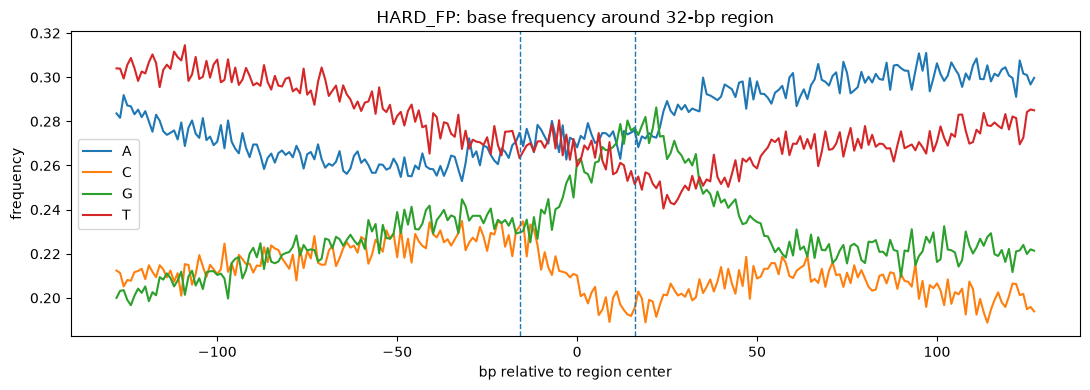

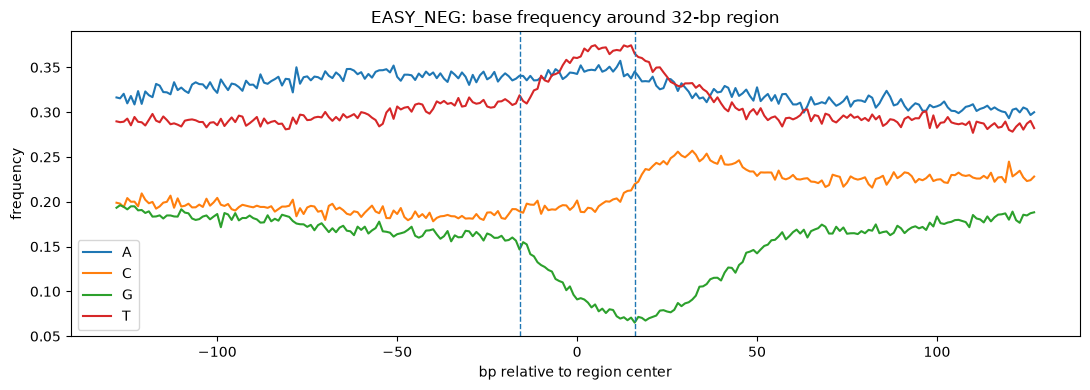

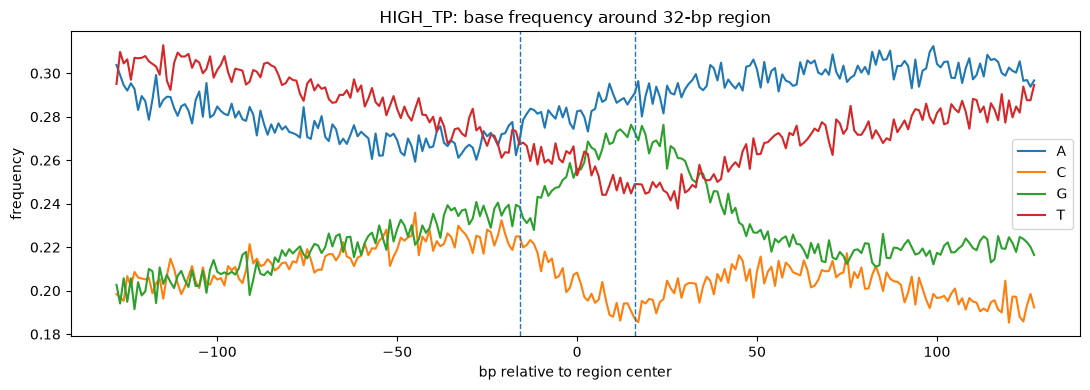

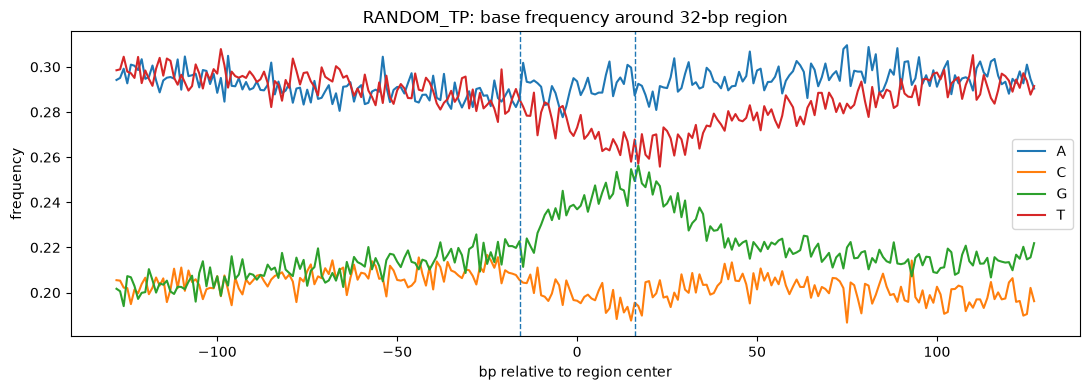

In [16]:
# ============================================================
# OPTIONAL POSITIONAL BASE-FREQUENCY DIAGNOSTIC
# ============================================================

import matplotlib.pyplot as plt


def base_frequency_matrix(
    seqs,
):
    matrix = np.zeros(
        (
            len(
                BASES
            ),
            CONTEXT_BP,
        ),
        dtype=np.float64,
    )

    for seq in seqs:
        for pos, char in enumerate(
            seq
        ):
            idx = np.flatnonzero(
                BASES
                == char
            )

            if idx.size:
                matrix[
                    int(
                        idx[0]
                    ),
                    pos,
                ] += 1.0

    matrix /= max(
        len(
            seqs
        ),
        1,
    )

    return matrix


relative_position = (
    np.arange(
        CONTEXT_BP
    )
    - HALF_CONTEXT
)

for group_name in (
    "HARD_FP",
    "EASY_NEG",
    "HIGH_TP",
    "RANDOM_TP",
):
    seqs = (
        selection.loc[
            selection[
                "group"
            ]
            == group_name,
            "seq_context256",
        ]
        .tolist()
    )

    matrix = (
        base_frequency_matrix(
            seqs
        )
    )

    plt.figure(
        figsize=(
            11,
            4,
        )
    )

    for base_index, base in enumerate(
        BASES[
            :4
        ]
    ):
        plt.plot(
            relative_position,
            matrix[
                base_index
            ],
            label=base,
        )

    plt.axvline(
        -16,
        linestyle="--",
        linewidth=1,
    )

    plt.axvline(
        16,
        linestyle="--",
        linewidth=1,
    )

    plt.title(
        f"{group_name}: base frequency around 32-bp region"
    )

    plt.xlabel(
        "bp relative to region center"
    )

    plt.ylabel(
        "frequency"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


In [17]:
# ============================================================
# SAVE RESULTS
# ============================================================

OUT_DIR = (
    EXP033_RUN_DIR
    / "false_positive_study"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TOP_FP_PATH = (
    OUT_DIR
    / "top_10000_false_positives.csv"
)

GROUPS_PATH = (
    OUT_DIR
    / "diagnostic_sequence_groups.csv"
)

COMPOSITION_PATH = (
    OUT_DIR
    / "composition_summary.csv"
)

KMER_PATH = (
    OUT_DIR
    / "kmer6_enrichment.csv"
)

SIMILARITY_PATH = (
    OUT_DIR
    / "similarity_summary.csv"
)

SEPARABILITY_PATH = (
    OUT_DIR
    / "sequence_separability_auc.csv"
)

selection.loc[
    selection[
        "group"
    ]
    == "HARD_FP"
].sort_values(
    "score",
    ascending=False,
).to_csv(
    TOP_FP_PATH,
    index=False,
)

selection.to_csv(
    GROUPS_PATH,
    index=False,
)

composition_summary.to_csv(
    COMPOSITION_PATH,
    index=False,
)

kmer_enrichment.to_csv(
    KMER_PATH,
    index=False,
)

similarity_summary.to_csv(
    SIMILARITY_PATH,
    index=False,
)

separability.to_csv(
    SEPARABILITY_PATH,
    index=False,
)

print("Saved:", TOP_FP_PATH)
print("Saved:", GROUPS_PATH)
print("Saved:", COMPOSITION_PATH)
print("Saved:", KMER_PATH)
print("Saved:", SIMILARITY_PATH)
print("Saved:", SEPARABILITY_PATH)


Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\top_10000_false_positives.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\diagnostic_sequence_groups.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\composition_summary.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\kmer6_enrichment.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\similarity_summary.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\sequence_separability_auc.csv


# Как интерпретировать результат

Сначала смотрим три вещи.

### 1. `HARD_FP vs HIGH_TP` — 4-mer Logistic Regression

```text
AUC ≈ 0.50–0.60
```

Очень сильный признак того, что на простом локальном sequence уровне FP и TP похожи.

```text
AUC ≫ 0.70
```

Значит между ними есть заметные sequence differences. Тогда нельзя говорить,
что мы упёрлись в biological state ceiling: вероятно, модель ещё не извлекает часть
доступного sequence signal.

### 2. Корреляция 6-mer enrichment

Сравниваем:

```text
HARD_FP vs EASY_NEG
HIGH_TP vs EASY_NEG
```

Если enrichment-профили сильно коррелируют и overlap top enriched k-mers высокий,
hard FPs действительно несут похожий локальный motif vocabulary.

### 3. Positive-centroid similarity

Если `HARD_FP` существенно ближе к `HIGH_TP` centroid, чем к `EASY_NEG`,
это ещё один независимый индикатор promoter-like sequence structure.

---

Даже если все три теста покажут очень сильное сходство FP с positives, вывод должен быть:

> «Есть свидетельства sequence-only ambiguity / experimental-state dependence».

А не:

> «CNN уже невозможно улучшить».

Остаются более длинный context, motif grammar, точная позиционная структура,
модель capacity и stochastic/experimental noise.
